=== 1. 加载地理信息与海陆掩膜 ===
✅ 经纬度与海陆掩膜加载成功！

=== 2. 计算几何角度 (20250923000000) ===
✅ 角度计算完成！

=== 3. 读取表观反射率 & 筛选暗像元 ===
✅ 筛选完毕！有效暗像元数量: 910096

=== 4. 估算地表反射率 (基于 GOES ATBD) ===
✅ 地表反射率估算完成！

=== 正在生成对比图像 ===


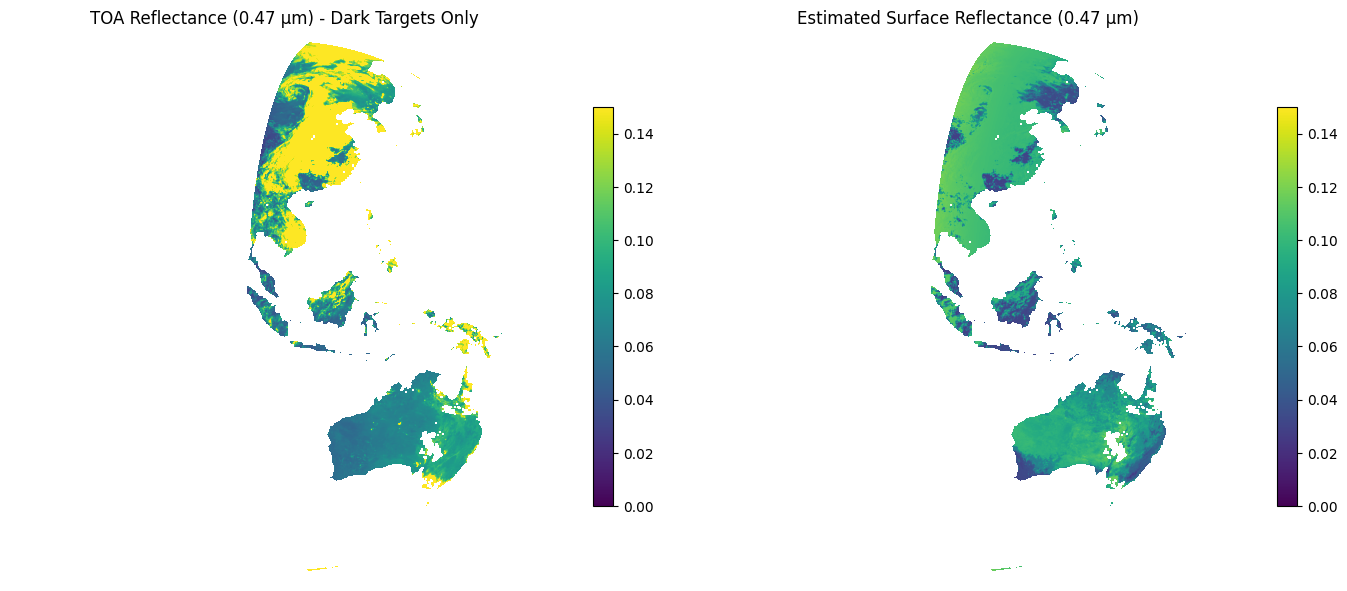

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pyorbital import astronomy

# ==========================================
# 1. 基础地理与掩膜加载
# ==========================================
def load_nav_and_mask(raw_file_path, mask_file_path):
    print("=== 1. 加载地理信息与海陆掩膜 ===")
    GRID_SIZE = 2748
    
    # 读经纬度
    raw_data = np.fromfile(raw_file_path, dtype='<f8')
    lat_flat = raw_data[0::2]
    lon_flat = raw_data[1::2]
    lats = lat_flat.reshape((GRID_SIZE, GRID_SIZE), order='F').T
    lons = lon_flat.reshape((GRID_SIZE, GRID_SIZE), order='F').T 
    
    # 读已保存的掩膜
    land_mask = np.load(mask_file_path)
    print("✅ 经纬度与海陆掩膜加载成功！")
    return lats, lons, land_mask

# ==========================================
# 2. 几何角度计算 (修正版)
# ==========================================
def calculate_fy4b_angles(lats, lons, utc_time_str):
    print(f"\n=== 2. 计算几何角度 ({utc_time_str}) ===")
    utc_time = datetime.strptime(utc_time_str, '%Y%m%d%H%M%S')
    valid_mask = (lats >= -90) & (lats <= 90) & (lons >= -180) & (lons <= 180)
    
    # 太阳角度
    sun_alt_rad, sun_azi_rad = astronomy.get_alt_az(utc_time, lons, lats)
    SZA = 90.0 - np.degrees(sun_alt_rad)
    SAA = np.degrees(sun_azi_rad)
    
    # 卫星角度
    SAT_LON = 105.0 
    Re = 6378.137
    H = 42164.0
    rs = H / Re

    lat_rad = np.radians(lats)
    lon_rad = np.radians(lons)
    sat_lon_rad = np.radians(SAT_LON)
    
    lon_diff = sat_lon_rad - lon_rad
    cos_beta = np.cos(lat_rad) * np.cos(lon_diff)
    sin_beta = np.sqrt(1 - cos_beta**2)
    
    vza_rad = np.arctan2(sin_beta, cos_beta - (1 / rs))
    VZA = np.degrees(vza_rad)
    VZA = np.where(cos_beta < (1 / rs), np.nan, VZA)

    vaa_rad = np.arctan2(np.sin(lon_diff), -np.sin(lat_rad) * np.cos(lon_diff))
    VAA = np.degrees(vaa_rad)
    VAA = (VAA + 360) % 360 

    # 相对方位角
    RAA = np.abs(SAA - VAA) % 360
    RAA = np.where(RAA > 180, 360 - RAA, RAA)

    # 清理无效区
    SZA[~valid_mask] = np.nan
    VZA[~valid_mask] = np.nan
    RAA[~valid_mask] = np.nan
    
    print("✅ 角度计算完成！")
    return SZA, VZA, RAA

# ==========================================
# 3. 数据读取与暗像元筛选
# ==========================================
def read_and_filter_fy4b_data(hdf_file_path, sza, vza, land_mask):
    print("\n=== 3. 读取表观反射率 & 筛选暗像元 ===")
    channels_needed = {'01': 'rho_047', '02': 'rho_065', '03': 'rho_0825', '06': 'rho_225'}
    toa_dict = {}
    
    with h5py.File(hdf_file_path, 'r') as f:
        for ch_str, name in channels_needed.items():
            data_name = f"NOMChannel{ch_str}"
            cal_name = f"CALChannel{ch_str}"
            
            dn_data = f['Data'][data_name][()] if 'Data' in f else f[data_name][()]
            cal_table = f['Calibration'][cal_name][()] if 'Calibration' in f else f[cal_name][()]
            
            physical_data = np.full(dn_data.shape, np.nan, dtype=np.float32)
            valid_dn_mask = dn_data < 65000
            physical_data[valid_dn_mask] = cal_table[dn_data[valid_dn_mask]]
            toa_dict[name] = physical_data
            
    r047, r065, r225 = toa_dict['rho_047'], toa_dict['rho_065'], toa_dict['rho_225']
    
    # 构建筛子 (条件与你之前确认的一致)
    cond_valid = (r047 > 0) & (r065 > 0) & (r225 > 0)
    cond_geom = (sza >= 0) & (sza <= 80) & (vza >= 0) & (vza <= 80)
    cond_land = (land_mask == 1)
    cond_cloud = (r047 < 0.4)
    cond_dark = (r225 < 0.25)
    
    final_mask = cond_valid & cond_geom & cond_land & cond_cloud & cond_dark
    
    print(f"✅ 筛选完毕！有效暗像元数量: {np.sum(final_mask)}")
    return toa_dict, final_mask

# ==========================================
# 4. 估算地表反射率
# ==========================================
def estimate_surface_reflectance(toa_dict, sza_matrix, final_mask):
    print("\n=== 4. 估算地表反射率 (基于 GOES ATBD) ===")
    
    r047 = toa_dict['rho_047']
    r065 = toa_dict['rho_065']
    r0825 = toa_dict['rho_0825']
    r225 = toa_dict['rho_225']
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ndvi = (r0825 - r065) / (r0825 + r065)
    
    rho_047_surf = np.full_like(r047, np.nan)
    rho_065_surf = np.full_like(r065, np.nan)
    
    # 仅在 final_mask (暗像元) 上进行计算，节约算力
    m1 = final_mask & (ndvi >= 0.55)
    m2 = final_mask & (ndvi >= 0.3) & (ndvi < 0.55)
    m3 = final_mask & (ndvi >= 0.2) & (ndvi < 0.3)
    m4 = final_mask & (ndvi < 0.2)
    
    def apply_formula(mask, c1, c2, c3, c4, target_surf):
        if np.any(mask):
            target_surf[mask] = (c1 + c2 * sza_matrix[mask]) + (c3 + c4 * sza_matrix[mask]) * r225[mask]
            
    apply_formula(m1,  1.436330E-02,  2.060893E-04,  1.749239E-01, -2.859502E-03, rho_047_surf)
    apply_formula(m1,  1.374160E-02, -5.128175E-05,  2.761044E-01,  1.034823E-03, rho_065_surf)
    
    apply_formula(m2,  4.163894E-02, -2.147513E-04,  1.598440E-01,  7.401292E-04, rho_047_surf)
    apply_formula(m2,  2.990101E-02, -1.873911E-04,  4.602174E-01,  9.658934E-04, rho_065_surf)
    
    apply_formula(m3,  5.154307E-02,  5.679386E-05,  2.048702E-01, -7.064656E-04, rho_047_surf)
    apply_formula(m3,  5.179930E-02, -1.043257E-04,  4.937035E-01,  4.310074E-04, rho_065_surf)
    
    apply_formula(m4, -4.990575E-02,  2.138207E-03,  8.498076E-01, -1.179596E-02, rho_047_surf)
    apply_formula(m4, -3.397737E-02,  1.640336E-03,  1.087497E+00, -9.538776E-03, rho_065_surf)
    
    rho_047_surf = np.clip(rho_047_surf, 0.001, 1.0)
    rho_065_surf = np.clip(rho_065_surf, 0.001, 1.0)
    
    print("✅ 地表反射率估算完成！")
    return rho_047_surf, rho_065_surf

# ==========================================
# 5. 主程序与可视化验证
# ==========================================
if __name__ == "__main__":
    # ⚠️ 请根据你的实际情况修改以下 4 个参数 ⚠️
    RAW_FILE = "FY4B-_DISK_1050E_GEO_NOM_LUT_20240227000000_4000M_V0001.raw"
    MASK_FILE = "FY4B_LandMask_4km.npy"
    HDF_FILE = "FY4B-_AGRI--_N_DISK_1050E_L1-_FDI-_MULT_NOM_20250923000000_20250923001459_4000M_V0001.HDF"
    # 从 HDF 文件名提取的时间 (UTC)
    OBS_TIME = "20250923000000" 

    # 执行流水线
    lats, lons, land_mask = load_nav_and_mask(RAW_FILE, MASK_FILE)
    sza, vza, raa = calculate_fy4b_angles(lats, lons, OBS_TIME)
    toa_dict, final_mask = read_and_filter_fy4b_data(HDF_FILE, sza, vza, land_mask)
    rho_047_surf, rho_065_surf = estimate_surface_reflectance(toa_dict, sza, final_mask)

    # --- 绘图展示战果 ---
    print("\n=== 正在生成对比图像 ===")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 图1: 卫星看到的蓝光 (TOA) - 只展示符合暗像元条件的像素
    toa_plot = np.where(final_mask, toa_dict['rho_047'], np.nan)
    im1 = axes[0].imshow(toa_plot, cmap='viridis', vmin=0, vmax=0.15)
    axes[0].set_title("TOA Reflectance (0.47 µm) - Dark Targets Only")
    plt.colorbar(im1, ax=axes[0], shrink=0.7)
    axes[0].axis('off')

    # 图2: 我们推算出的地表蓝光 (Surface)
    surf_plot = np.where(final_mask, rho_047_surf, np.nan)
    im2 = axes[1].imshow(surf_plot, cmap='viridis', vmin=0, vmax=0.15)
    axes[1].set_title("Estimated Surface Reflectance (0.47 µm)")
    plt.colorbar(im2, ax=axes[1], shrink=0.7)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()